In [ ]:
import pandas as pd
df = pd.read_csv("/content/cleaned_pytracebugs_2.csv")

/tmp/ipython-input-4143622653.py:2: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263

In [ ]:
new_df = df[["code", "status", "labels"]]

In [ ]:
new_df.head(100)

,code,status,labels
0,"def plot(result_dict_file, show, plot_save_fil...",Buggy,1
1,def stream_logs(self): for line in self.api.re...,Buggy,1
2,"def addRecentProjectFile(self, projectFile): p...",Buggy,1
3,"def addSfmAugmentation(self, withMVS=False): s...",Buggy,1
4,def load_pymathics_doc(self): if self.pymathic...,Buggy,1
...,...,...,...
95,"def __init__(self, host='127.0.0.1', port=9200...",Buggy,1
96,"def flush_queued_events(self, retry_count=0): ...",Buggy,1
97,"def run(self, name, index, username): es = Ela...",Buggy,1
98,"def run(self, file_path, sketch_id, username, ...",Buggy,1


In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28238 entries, 0 to 28237
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   code    28238 non-null  object
 1   status  28236 non-null  object
 2   labels  28236 non-null  object
dtypes: object(3)
memory usage: 662.0+ KB


In [ ]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

new_df = new_df.copy()

new_df['labels'] = pd.to_numeric(new_df['labels'], errors='coerce')

new_df.dropna(subset=['labels'], inplace=True)

new_df['labels'] = new_df['labels'].astype(int)

In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28234 entries, 0 to 28237
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   code    28234 non-null  object
 1   status  28234 non-null  object
 2   labels  28234 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 882.3+ KB


In [ ]:
import pandas as pd

new_df = new_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(new_df.head(100))


                                                 code    status  labels
0   def focusin(): print("focus in") if v is c.p.v...  Accepted       0
1   def list_sizes(provider="all"): " List cloud p...  Accepted       0
2   def title(self, obj): return _("Recent changes...  Accepted       0
3   def manageWebCache(self): if sys.platform.star...  Accepted       0
4   def update_def(self, name, part_number, head, ...  Accepted       0
..                                                ...       ...     ...
95  def close(self): " Close the session " self.se...  Accepted       0
96  def add_binstar_token(url): clean_url, token =...     Buggy       1
97  def canExpandAllSubheads(self): c = self for p...  Accepted       0
98  def _call_input_tensor(self, input_tensor, ind...     Buggy       1
99  def has_key(key): " Check if key is in the min...  Accepted       0

[100 rows x 3 columns]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(new_df['code'], new_df['labels'], test_size=0.2, random_state=42, stratify=new_df['labels'])

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=50000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
MAX_LEN = 300
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 128

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(pool_size=2),
    LSTM(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - accuracy: 0.5599 - loss: 0.6657 - val_accuracy: 0.8207 - val_loss: 0.4738
Epoch 2/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8684 - loss: 0.3286 - val_accuracy: 0.9181 - val_loss: 0.2077
Epoch 3/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9461 - loss: 0.1577 - val_accuracy: 0.9245 - val_loss: 0.1866
Epoch 4/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9706 - loss: 0.0951 - val_accuracy: 0.9278 - val_loss: 0.1958
Epoch 5/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9786 - loss: 0.0711 - val_accuracy: 0.9303 - val_loss: 0.2228
Epoch 6/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9892 - loss: 0.0358 - val_accuracy: 0.9245 - val_loss: 0.3163
Epoch 7/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9924 - loss: 0.0264 - val_accuracy: 0.9290 - val_loss: 0.3454
Epoch 8/10
283/283 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.9939 - loss: 0.0203 - val_acc

In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {acc:.4f}")

177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9279 - loss: 0.3316
Test Accuracy: 0.9267


In [ ]:
from sklearn.metrics import f1_score

y_pred_prob = model.predict(X_test_pad)

y_pred = (y_pred_prob > 0.5).astype(int).flatten()


177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [ ]:
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)

F1-score: 0.9277739009071877


In [ ]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.914059814369199
Recall: 0.9419057739992915


In [ ]:
f1 = f1_score(y_test, y_pred, average='weighted')  # or 'macro', 'micro'


In [ ]:
from tensorflow.keras.models import save_model
import pickle

model.save("bug_detection_model.h5")

with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
from google.colab import files

files.download("bug_detection_model.h5")
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

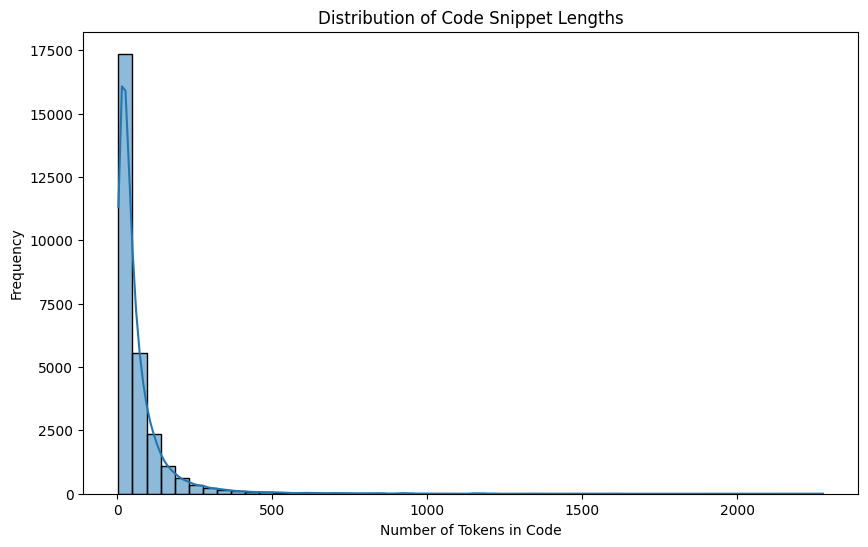

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

new_df['code_length'] = new_df['code'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10,6))
sns.histplot(new_df['code_length'], bins=50, kde=True)
plt.title("Distribution of Code Snippet Lengths")
plt.xlabel("Number of Tokens in Code")
plt.ylabel("Frequency")
plt.show()



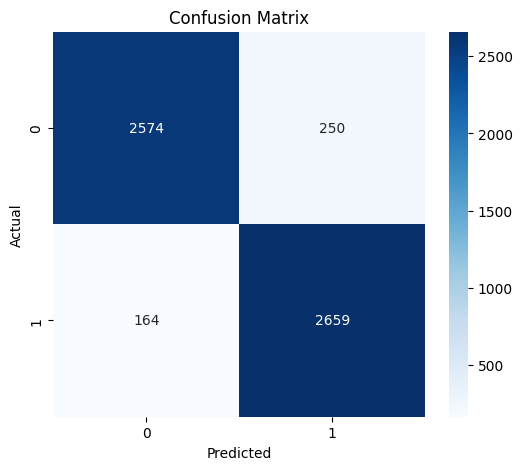

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

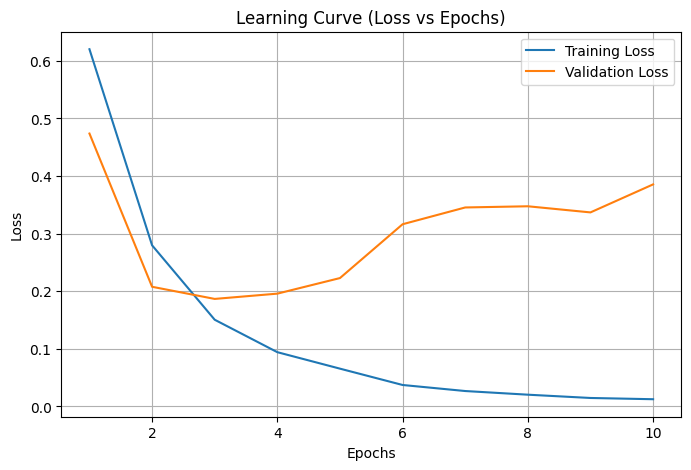

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Learning Curve (Loss vs Epochs)')
plt.legend()
plt.grid(True)
plt.show()